In [15]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [16]:
!nvidia-smi

Sun Aug  9 23:02:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.57                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti     On  |   00000000:2D:00.0  On |                  N/A |
|  0%   38C    P8             17W /  300W |    1502MiB /  16303MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Tensors

In [17]:
torch.__version__

'2.13.0+cu129'

In [18]:
scalar = torch.tensor(7)
print(scalar.ndim)
scalar.device

0


device(type='cpu')

In [19]:
scalar_on_gpu = scalar.to(device)

In [20]:
scalar.device

device(type='cpu')

In [21]:
vector = torch.tensor([7, 7])
print(vector.ndim)
print(vector.shape)
vector

1
torch.Size([2])


tensor([7, 7])

In [22]:
matrix = torch.tensor([[7, 8], 
                       [8, 9]])
print(matrix.ndim)
print(matrix.shape)
matrix

2
torch.Size([2, 2])


tensor([[7, 8],
        [8, 9]])

In [23]:
tensor = torch.tensor([[[1, 2, 3],
                        [3, 6, 9],
                        [2, 4, 5]]])
print(tensor.ndim)
print(tensor.shape)
tensor

3
torch.Size([1, 3, 3])


tensor([[[1, 2, 3],
         [3, 6, 9],
         [2, 4, 5]]])

In [24]:
random_tensor = torch.rand(size=(1, 3, 3))
random_tensor

tensor([[[0.8585, 0.9760, 0.6388],
         [0.4133, 0.8100, 0.8881],
         [0.1465, 0.6299, 0.9853]]])

### Multiplication

In [25]:
# Element-wise
tensor_1 = torch.rand(size=(1, 2, 2))
tensor_2 = torch.rand(size=(1, 2, 2))
tensor_1 * tensor_2

tensor([[[0.6085, 0.0056],
         [0.7806, 0.1720]]])

In [26]:
# Matrix multiplication
tensor_1 = torch.rand(size=(1, 2, 3))
tensor_2 = torch.rand(size=(1, 3, 3))
tensor_1 @ tensor_2

torch.matmul(tensor_1, tensor_2)

tensor([[[1.4603, 0.9443, 1.1431],
         [1.2513, 0.9214, 0.6644]]])

### Linear Regression

In [85]:
class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = torch.nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias = torch.nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x: torch.Tensor):
        return self.weights * x + bias


model = LinearRegressionModel()

In [86]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = model.to(device='cuda')
X_train = X_train.to(device='cuda')
X_test = X_test.to(device='cuda')
y_train = y_train.to(device='cuda')
y_test = y_test.to(device='cuda')

Epoch: 0 | Train Loss: 0.07592163234949112 | Test Loss: 0.07816499471664429 
Epoch: 10 | Train Loss: 0.06675497442483902 | Test Loss: 0.06872747093439102 
Epoch: 20 | Train Loss: 0.05869506672024727 | Test Loss: 0.060429420322179794 
Epoch: 30 | Train Loss: 0.05160832405090332 | Test Loss: 0.05313326045870781 
Epoch: 40 | Train Loss: 0.045377206057310104 | Test Loss: 0.04671803116798401 
Epoch: 50 | Train Loss: 0.039898425340652466 | Test Loss: 0.04107735678553581 
Epoch: 60 | Train Loss: 0.03508113697171211 | Test Loss: 0.036117732524871826 
Epoch: 70 | Train Loss: 0.030845491215586662 | Test Loss: 0.0317569263279438 
Epoch: 80 | Train Loss: 0.02712124027311802 | Test Loss: 0.027922628447413445 
Epoch: 90 | Train Loss: 0.023846661671996117 | Test Loss: 0.024551287293434143 
Epoch: 100 | Train Loss: 0.020967448130249977 | Test Loss: 0.021587003022432327 
Epoch: 110 | Train Loss: 0.018435871228575706 | Test Loss: 0.018980618566274643 
Epoch: 120 | Train Loss: 0.016209950670599937 | Test

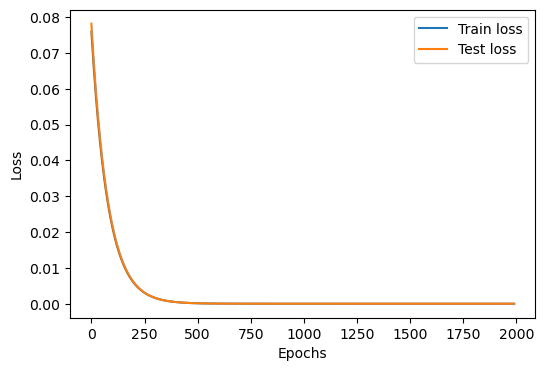

In [87]:
epochs = 2000
loss_fn = torch.nn.MSELoss() # torch.nn.L1Loss() 
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training
    model.train()                   # Set model in training mode
    y_pred = model(X_train)         # Forward pass on train data
    loss = loss_fn(y_pred, y_train) # Calculate the loss
    optimizer.zero_grad()           # Accumulated by default, set to zero so they are recalculated
    loss.backward()                 # Loss backpropagation w/ respect to every model parameter
    optimizer.step()                # Update parameters with `requires_grad=True`

    ### Testing
    model.eval()                    # Set model in test mode

    with torch.inference_mode(): 
      test_pred = model(X_test)                                 # Forward pass on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float))  # Caculate loss on test data

      # Print log
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())
            print(f"Epoch: {epoch} | Train Loss: {loss} | Test Loss: {test_loss} ")


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(epoch_count, train_loss_values, label="Train loss")
ax.plot(epoch_count, test_loss_values, label="Test loss")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

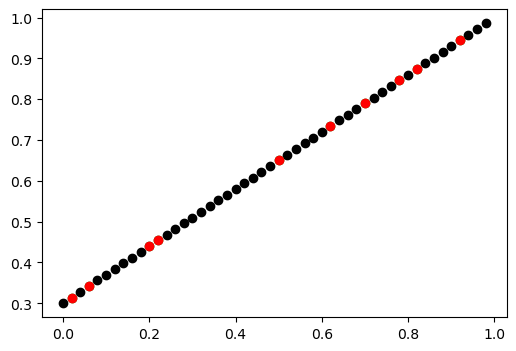

weights
tensor([0.7000])
bias
tensor([1.5074])


In [90]:
model.eval()

with torch.inference_mode():
    y_preds = model(X_test)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(X_train.detach().cpu().numpy(), y_train.detach().cpu().numpy(), color='black')
ax.scatter(X_test.detach().cpu().numpy(), y_test.detach().cpu().numpy(), color='green')
ax.scatter(X_test.detach().cpu().numpy(), y_preds.detach().cpu().numpy(), color='red')
plt.show()

for name, param in model.named_parameters():
    print(name)
    print(param.detach().cpu())

LinearRegressionModel()

device(type='cuda', index=0)

### Linear layer

$ y = A \cdot x + b$

In [31]:
linear = torch.nn.Linear(in_features=3, out_features=6)
x = torch.tensor([[1, 2, 3],
                  [3, 4, 5],
                  [5, 6, 7]], dtype=torch.float32)

output = linear(x)
print(f"Input shape: {x.shape}\n")
print(f"Output:\n{output}\n\nOutput shape: {output.shape}")

Input shape: torch.Size([3, 3])

Output:
tensor([[-0.2849,  0.9200, -0.2558,  1.2729, -0.3674, -1.2842],
        [ 0.1212,  1.9957, -0.8518,  2.9684, -0.6026, -2.4665],
        [ 0.5272,  3.0713, -1.4478,  4.6638, -0.8378, -3.6488]],
       grad_fn=<AddmmBackward0>)

Output shape: torch.Size([3, 6])
